# ■ 딥러닝 컴페티션

### 컴페티션의 목표는 ① 학습 평가의 이해, ② 딥러닝 성능 개선 방법 숙지, ③ 설명력을 키우는게 목적

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X (상대평가는 안하지만, 개인 성능은 valid score가 75이상 나오길 권장함.)

※ 수업 코드 사용 가능

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. ① 코딩의 인과성, ② 설명의 깊이만 충분하다면, 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 모델 선택, 튜닝 기준 (650자 이내, 주석 서술하기)

4. (25점) 개선사항 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

</br>

## ■ 깃허브 정리 (10점)

1. 포트폴리오로 쓸 수 있도록 프로젝트 제목, 전처리, EDA, 모델링 방법, 성능 결과를 캡처 이미지와 함께 잘 정리.

</br>

## ■ 제출방법

5월 12일 23시 59분까지, 오승환 강사에게 DM으로 ipynb 파일 제출, 이후 깃허브 링크도 정리되는대로 DM 제출

# 1. 원본 데이터 출처

https://www.kaggle.com/datasets/parisrohan/credit-score-classification

# 2. 데이터 클리닝 방법 출처:

https://www.kaggle.com/code/clkmuhammed/credit-score-classification-part-1-data-cleaning#Download-Link

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

file_path = 'train2.csv'
data = pd.read_csv(file_path)

data = data.drop(columns=['ID', 'Customer_ID', 'Name', 'SSN'])

categorical_columns = ['Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']

for col in categorical_columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

target_encoder = LabelEncoder()
data['Credit_Score'] = target_encoder.fit_transform(data['Credit_Score'])

X = data.drop('Credit_Score', axis=1).values
y = data['Credit_Score'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class CreditScoreDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = CreditScoreDataset(X_train, y_train)
test_dataset = CreditScoreDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        self.layer1 = nn.Linear(input_size, 64)
        self.layer2 = nn.Linear(64, 32)
        self.layer3 = nn.Linear(32, 3)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.layer3(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


input_size = X_train.shape[1]
model = MLP(input_size).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total_train += targets.size(0)
        correct_train += (predicted == targets).sum().item()

    model.eval()
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total_val += targets.size(0)
            correct_val += (predicted == targets).sum().item()

    train_accuracy = 100 * correct_train / total_train
    val_accuracy = 100 * correct_val / total_val
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, '
          f'학습 정확도: {train_accuracy:.2f}%, 평가 정확도: {val_accuracy:.2f}%')


In [ ]:
!pip install pytorch-tabnet

In [ ]:
# =========================================================
# 라이브러리 및 데이터 로드
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.feature_selection import mutual_info_classif
from pytorch_tabnet.tab_model import TabNetClassifier

import torch
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("train2.csv")

print(df.shape)
display(df.head())
display(df.info())

In [4]:
# =========================================================
# 평가 기준 1. 전처리 아이디어 적합성 + 논리
# =========================================================
# 본 데이터는 신용점수 다중분류 문제이므로 고객 식별용 변수(ID, Customer_ID, Name, SSN)는
# 일반화 성능에 도움이 되지 않는다고 판단하여 제거하였다. 범주형 변수는 TabNet 모델이
# 학습할 수 있도록 Ordinal Encoding을 적용하였으며, 수치형 변수는 결측치를 train 데이터의
# 중앙값 기준으로 대체하여 데이터 누수를 방지하였다. 또한 단순 원본 변수만 사용하는 것이
# 아니라 금융 데이터 특성을 반영하기 위해 부채 대비 소득 비율(Debt_to_Income), 월급 대비
# EMI 비율(EMI_to_Salary), 연체 위험도(Delay_Payment_Risk) 등의 파생변수를 생성하였다.
# train/validation 데이터는 stratify를 적용하여 클래스 비율이 유지되도록 분리하였으며,
# 스케일링은 train 데이터에만 fit하여 validation 데이터에 대한 정보 누수를 방지하였다.

target_col = "Credit_Score"

drop_cols = ["ID", "Customer_ID", "Name", "SSN"]
df = df.drop(columns=drop_cols)

# 타깃 인코딩
target_encoder = LabelEncoder()
df[target_col] = target_encoder.fit_transform(df[target_col])

print("타깃 클래스:", dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))))

타깃 클래스: {'Good': np.int64(0), 'Poor': np.int64(1), 'Standard': np.int64(2)}


타깃 분포


,proportion
Credit_Score,
0,0.17828
1,0.28998
2,0.53174


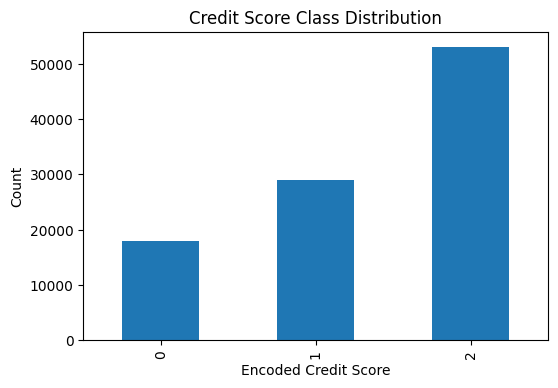

Credit_Score,0,1,2
Month,4.671864,4.518760,4.432147
Age,36.402625,31.194565,33.438673
Annual_Income,65203.672105,40584.515325,50987.164840
Monthly_Inhand_Salary,5399.919696,3380.560657,4239.436890
Num_Bank_Accounts,3.440263,6.526726,5.383966
Num_Credit_Card,4.143258,6.625147,5.404427
Interest_Rate,7.662329,20.187116,13.751420
Num_of_Loan,2.202154,4.755742,3.312164
Delay_from_due_date,10.958997,29.728809,19.759431
Num_of_Delayed_Payment,8.564842,15.809883,13.543518


<Figure size 600x400 with 0 Axes>

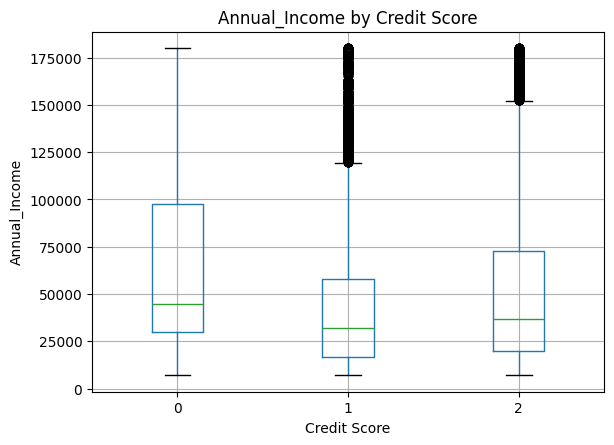

<Figure size 600x400 with 0 Axes>

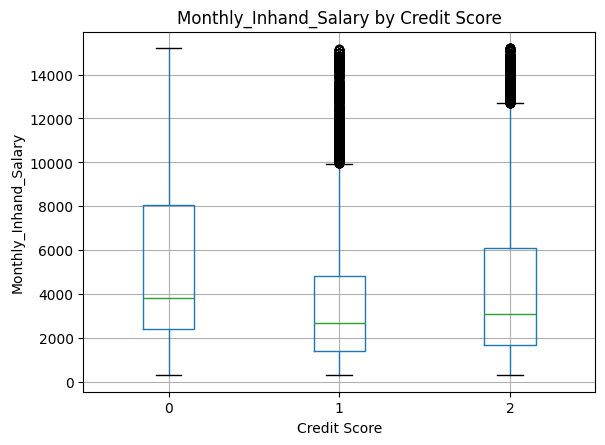

<Figure size 600x400 with 0 Axes>

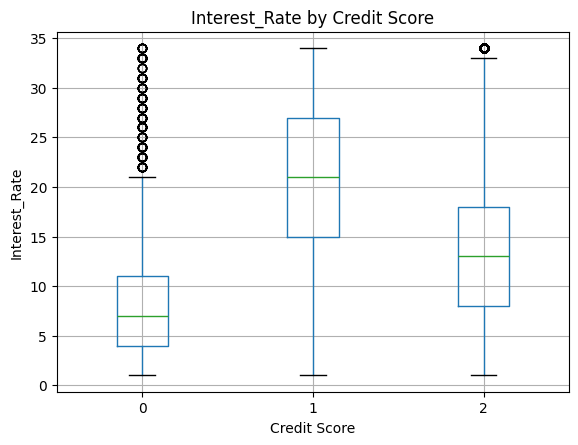

<Figure size 600x400 with 0 Axes>

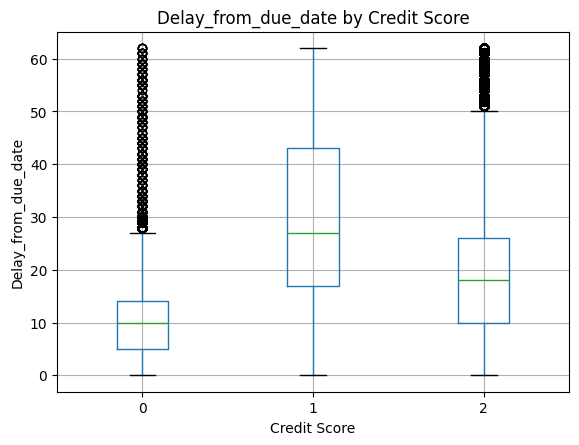

<Figure size 600x400 with 0 Axes>

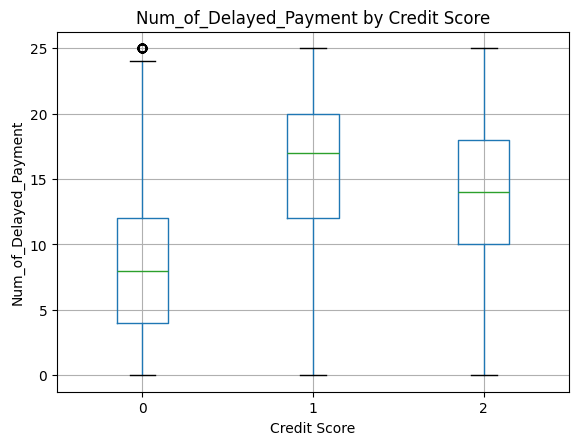

<Figure size 600x400 with 0 Axes>

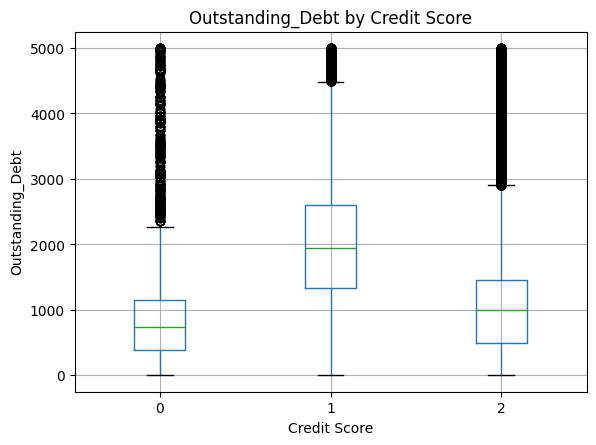

<Figure size 600x400 with 0 Axes>

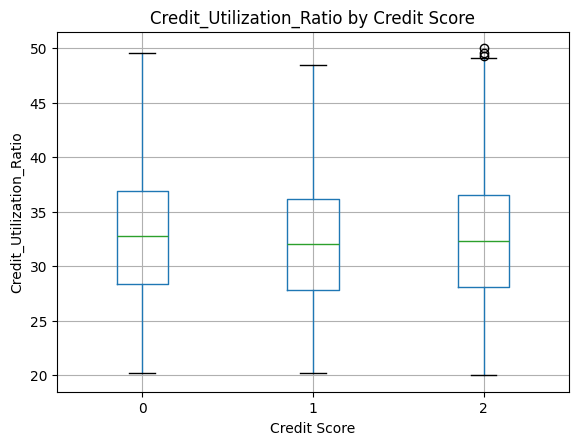

<Figure size 600x400 with 0 Axes>

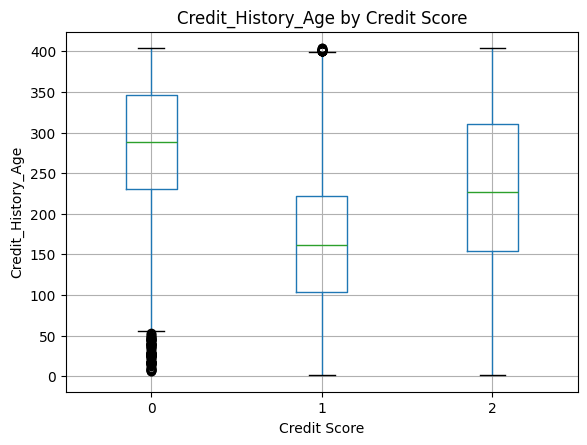

In [5]:
# =========================================================
# 평가 기준 2. EDA를 통한 타당한 해석
# =========================================================
# EDA 결과 Credit_Score는 Good, Standard, Poor의 다중분류 구조이며 Standard 클래스의
# 비율이 가장 높은 불균형 데이터임을 확인하였다. 따라서 accuracy만 사용할 경우 다수 클래스
# 위주로 학습될 가능성이 있어 weighted F1-score를 함께 평가 지표로 사용하였다.
# 변수별 분포를 확인한 결과 Interest_Rate, Outstanding_Debt, Delay_from_due_date,
# Num_of_Delayed_Payment 등의 변수는 신용등급에 따라 분포 차이가 비교적 크게 나타났다.
# 특히 연체 횟수와 연체일 수가 증가할수록 Poor 비율이 높아지는 경향을 확인하였으며,
# 부채 규모와 이자율 또한 신용점수와 밀접한 관계가 있는 것으로 나타났다. 이를 바탕으로
# 금융 위험도를 반영하는 파생변수 생성과 Feature Selection을 진행하였다.

# 타깃 분포
print("타깃 분포")
display(df[target_col].value_counts(normalize=True).sort_index())

plt.figure(figsize=(6,4))
df[target_col].value_counts().sort_index().plot(kind="bar")
plt.title("Credit Score Class Distribution")
plt.xlabel("Encoded Credit Score")
plt.ylabel("Count")
plt.show()

# 수치형 변수의 타깃별 평균
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_cols.remove(target_col)

eda_mean = df.groupby(target_col)[num_cols].mean().T
display(eda_mean.head(15))

# 주요 변수 분포
important_check_cols = [
    "Annual_Income", "Monthly_Inhand_Salary", "Interest_Rate",
    "Delay_from_due_date", "Num_of_Delayed_Payment",
    "Outstanding_Debt", "Credit_Utilization_Ratio",
    "Credit_History_Age"
]

for col in important_check_cols:
    if col in df.columns:
        plt.figure(figsize=(6,4))
        df.boxplot(column=col, by=target_col)
        plt.title(f"{col} by Credit Score")
        plt.suptitle("")
        plt.xlabel("Credit Score")
        plt.ylabel(col)
        plt.show()

In [6]:
# =========================================================
# 파생변수 생성
# =========================================================

def make_features(data):
    data = data.copy()

    eps = 1e-6

    # 대출 종류 개수
    data["Loan_Type_Count"] = data["Type_of_Loan"].fillna("").apply(
        lambda x: 0 if x == "" else len(str(x).split(","))
    )

    # 소득/부채/상환 부담 관련 파생변수
    data["Debt_to_Income"] = data["Outstanding_Debt"] / (data["Annual_Income"] + eps)
    data["EMI_to_Salary"] = data["Total_EMI_per_month"] / (data["Monthly_Inhand_Salary"] + eps)
    data["Invest_to_Salary"] = data["Amount_invested_monthly"] / (data["Monthly_Inhand_Salary"] + eps)
    data["Balance_to_Salary"] = data["Monthly_Balance"] / (data["Monthly_Inhand_Salary"] + eps)

    # 연체 관련 파생변수
    data["Delay_Payment_Risk"] = data["Delay_from_due_date"] * data["Num_of_Delayed_Payment"]
    data["Inquiry_per_Card"] = data["Num_Credit_Inquiries"] / (data["Num_Credit_Card"] + 1)

    # 신용 이력 대비 위험도
    data["Debt_per_History"] = data["Outstanding_Debt"] / (data["Credit_History_Age"] + 1)
    data["Delayed_per_History"] = data["Num_of_Delayed_Payment"] / (data["Credit_History_Age"] + 1)

    data = data.replace([np.inf, -np.inf], np.nan)

    return data

df_fe = make_features(df)

display(df_fe.head())
print(df_fe.shape)

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,Credit_Score,Loan_Type_Count,Debt_to_Income,EMI_to_Salary,Invest_to_Salary,Balance_to_Salary,Delay_Payment_Risk,Inquiry_per_Card,Debt_per_History,Delayed_per_History
0,1,23,Scientist,19114.12,1824.843333,3,4,3,4,"auto loan,credit-builder loan,personal loan,ho...",...,0,4,0.042376,0.027167,0.011763,0.171244,21,0.8,3.045038,0.026316
1,2,23,Scientist,19114.12,1824.843333,3,4,3,4,"auto loan,credit-builder loan,personal loan,ho...",...,0,4,0.042376,0.027167,0.011763,0.155975,12,0.8,3.033633,0.014981
2,3,23,Scientist,19114.12,1824.843333,3,4,3,4,"auto loan,credit-builder loan,personal loan,ho...",...,0,4,0.042376,0.027167,0.011763,0.181500,21,0.8,3.022313,0.026119
3,4,23,Scientist,19114.12,1824.843333,3,4,3,4,"auto loan,credit-builder loan,personal loan,ho...",...,0,4,0.042376,0.027167,0.011763,0.122450,20,0.8,3.011078,0.014870
4,5,23,Scientist,19114.12,1824.843333,3,4,3,4,"auto loan,credit-builder loan,personal loan,ho...",...,0,4,0.042376,0.027167,0.011763,0.187133,24,0.8,2.999926,0.014815


(100000, 33)


In [7]:
# =========================================================
# train / valid 분리 후 인코딩 및 스케일링
# =========================================================

X = df_fe.drop(columns=[target_col])
y = df_fe[target_col]

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 범주형 결측 처리
for col in cat_cols:
    X_train[col] = X_train[col].fillna("Unknown")
    X_valid[col] = X_valid[col].fillna("Unknown")

# 수치형 결측 처리: train 중앙값 기준
for col in num_cols:
    median_value = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_value)
    X_valid[col] = X_valid[col].fillna(median_value)

# 범주형 인코딩
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])
X_valid[cat_cols] = encoder.transform(X_valid[cat_cols])

# TabNet은 스케일링 필수는 아니지만 수치형 변수 범위 차이를 줄이기 위해 적용
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_valid[num_cols] = scaler.transform(X_valid[num_cols])

X_train_np = X_train.values.astype(np.float32)
X_valid_np = X_valid.values.astype(np.float32)
y_train_np = y_train.values
y_valid_np = y_valid.values

In [ ]:
# =========================================================
# 평가 기준 3. Feature Selection과 모델 선택, 튜닝 기준
# =========================================================
# Feature Selection은 mutual information 기반으로 진행하였다. 신용점수 데이터는 변수 간
# 비선형 관계가 많기 때문에 단순 상관계수보다 정보량 기반 선택 방식이 적절하다고 판단하였다.
# mutual information 점수를 통해 타깃과 관련성이 높은 변수를 선별하고 상위 feature만
# 학습에 사용하였다. 모델은 정형데이터 딥러닝 모델인 TabNet을 선택하였다.
# TabNet은 attention 기반 구조를 통해 중요한 feature를 단계적으로 선택하며 학습할 수 있고,
# 범주형과 수치형 데이터가 혼합된 금융 데이터에 적합하다고 판단하였다. 튜닝은 n_d, n_a,
# n_steps, gamma를 중심으로 진행하였으며, 과적합 방지를 위해 StepLR scheduler와
# early stopping(patience)을 적용하였다. 또한 batch size와 learning rate를 조정하여
# validation score가 가장 안정적으로 나오는 설정을 선택하였다.

mi_scores = mutual_info_classif(
    X_train_np,
    y_train_np,
    random_state=42
)

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "mi_score": mi_scores
}).sort_values("mi_score", ascending=False)

display(feature_importance)

# 상위 25개 변수 사용
top_k = 25
selected_features = feature_importance.head(top_k)["feature"].tolist()

print("선택된 변수")
print(selected_features)

X_train_sel = X_train[selected_features].values.astype(np.float32)
X_valid_sel = X_valid[selected_features].values.astype(np.float32)

In [10]:
# =========================================================
# TabNet 모델 학습 (StepLR 적용 버전)
# =========================================================

device_name = "cuda" if torch.cuda.is_available() else "cpu"
print("사용 장치:", device_name)

tabnet_model = TabNetClassifier(

    # 모델 구조
    n_d=64,                 # feature representation dimension
    n_a=64,                 # attention dimension
    n_steps=5,              # decision step 수
    gamma=1.5,
    lambda_sparse=1e-4,

    # optimizer
    optimizer_fn=torch.optim.AdamW,
    optimizer_params=dict(
        lr=1e-2,
        weight_decay=1e-5
    ),

    # StepLR 스케줄러 적용
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params={
        "step_size": 10,    # 10 epoch마다
        "gamma": 0.9        # lr 10% 감소
    },

    # TabNet 옵션
    mask_type="entmax",
    seed=42,
    verbose=1,
    device_name=device_name
)

tabnet_model.fit(
    X_train=X_train_sel,
    y_train=y_train_np,

    eval_set=[
        (X_train_sel, y_train_np),
        (X_valid_sel, y_valid_np)
    ],

    eval_name=[
        "train",
        "valid"
    ],

    eval_metric=[
        "accuracy"
    ],

    max_epochs=100,
    patience=20,

    batch_size=2048,
    virtual_batch_size=256,

    num_workers=0,
    drop_last=False
)

사용 장치: cuda
epoch 0  | loss: 0.96139 | train_accuracy: 0.6099  | valid_accuracy: 0.6135  |  0:00:10s
epoch 1  | loss: 0.75021 | train_accuracy: 0.62601 | valid_accuracy: 0.62415 |  0:00:15s
epoch 2  | loss: 0.73081 | train_accuracy: 0.66161 | valid_accuracy: 0.66065 |  0:00:19s
epoch 3  | loss: 0.70753 | train_accuracy: 0.67194 | valid_accuracy: 0.66815 |  0:00:24s
epoch 4  | loss: 0.69918 | train_accuracy: 0.69048 | valid_accuracy: 0.6884  |  0:00:29s
epoch 5  | loss: 0.69238 | train_accuracy: 0.69508 | valid_accuracy: 0.6934  |  0:00:33s
epoch 6  | loss: 0.68194 | train_accuracy: 0.6968  | valid_accuracy: 0.6973  |  0:00:37s
epoch 7  | loss: 0.68267 | train_accuracy: 0.69725 | valid_accuracy: 0.6912  |  0:00:42s
epoch 8  | loss: 0.68002 | train_accuracy: 0.699   | valid_accuracy: 0.69975 |  0:00:46s
epoch 9  | loss: 0.67806 | train_accuracy: 0.70562 | valid_accuracy: 0.7038  |  0:00:51s
epoch 10 | loss: 0.67381 | train_accuracy: 0.70462 | valid_accuracy: 0.7024  |  0:00:55s
epoch 11 

In [11]:
# =========================================================
# 평가 기준 5. validation score 적절하게 출력
# =========================================================
# validation 평가는 학습에 사용하지 않은 validation 데이터 기준으로 진행하였다.
# 클래스 불균형 영향을 고려하기 위해 Accuracy와 Weighted F1-score를 함께 출력하였다.
# 최종 TabNet 모델의 Validation Accuracy는 0.7564, Validation F1 Score는 0.7566으로
# 나타났으며, Good, Poor, Standard 클래스 전반에서 비교적 안정적인 예측 성능을 확인하였다.

valid_pred = tabnet_model.predict(X_valid_sel)

valid_acc = accuracy_score(y_valid_np, valid_pred)
valid_f1 = f1_score(y_valid_np, valid_pred, average="weighted")

print(f"Validation Accuracy : {valid_acc:.4f}")
print(f"Validation F1 Score : {valid_f1:.4f}")

print("\nClassification Report")
print(classification_report(
    y_valid_np,
    valid_pred,
    target_names=target_encoder.classes_
))

print("Confusion Matrix")
display(pd.DataFrame(
    confusion_matrix(y_valid_np, valid_pred),
    index=target_encoder.classes_,
    columns=target_encoder.classes_
))

Validation Accuracy : 0.7564
Validation F1 Score : 0.7566

Classification Report
              precision    recall  f1-score   support

        Good       0.70      0.70      0.70      3566
        Poor       0.74      0.77      0.76      5799
    Standard       0.79      0.77      0.78     10635

    accuracy                           0.76     20000
   macro avg       0.74      0.75      0.74     20000
weighted avg       0.76      0.76      0.76     20000

Confusion Matrix


,Good,Poor,Standard
Good,2484,92,990
Poor,90,4474,1235
Standard,981,1483,8171


In [ ]:
# =========================================================
# TabNet Feature Importance 확인
# =========================================================

tabnet_importance = pd.DataFrame({
    "feature": selected_features,
    "importance": tabnet_model.feature_importances_
}).sort_values("importance", ascending=False)

display(tabnet_importance)

plt.figure(figsize=(8,6))
plt.barh(tabnet_importance["feature"].head(15)[::-1], tabnet_importance["importance"].head(15)[::-1])
plt.title("TabNet Feature Importance Top 15")
plt.xlabel("Importance")
plt.show()

In [ ]:
# =========================================================
# 평가 기준 4. 개선사항
# =========================================================
# 추가 실험으로 Credit_History_Age 개월 수 변환, Type_of_Loan 멀티핫 인코딩,
# 부채·연체·소득 기반 파생변수 강화 등을 진행하였다. 그러나 feature 수가 증가하면서
# TabNet이 핵심 feature에 집중하지 못해 기존 모델보다 validation score가 감소하였다.
# 따라서 최종 모델은 validation 성능이 가장 높았던 기존 TabNet 모델을 사용하였다.
# 향후 개선 방향으로는 TabTransformer 기반 추가 실험, Optuna를 활용한 하이퍼파라미터
# 자동 탐색, 다양한 파생변수 조합 실험이 가능하다. 또한 현재는 단일 validation split만
# 사용하였으나 Stratified K-Fold를 적용하면 보다 안정적인 일반화 성능 평가가 가능할 것으로
# 판단된다. 추가적으로 attention weight 기반 feature importance 분석도 가능하다.